# Diffusion Models on Three Dirac Atoms

## Motivation

**Denoising Diffusion Probabilistic Models (DDPM)** learn to reverse a Markov noising process.
By choosing a distribution simple enough to admit a *closed-form score*, we can study both
the forward and reverse dynamics exactly — without training a neural network.

## Mathematical Setting

We start from a discrete mixture of $K = 3$ Dirac atoms:
$$
p_0(x) = \frac{1}{K}\sum_{k=1}^{K} \delta(x - \mu_k), \qquad x \in \mathbb{R}^2.
$$

### Forward (noising) process

The DDPM forward kernel corrupts a sample by one step:
$$
x_{t+1} = \sqrt{\alpha_t}\, x_t + \sqrt{1-\alpha_t}\, \varepsilon_t, \qquad
\varepsilon_t \sim \mathcal{N}(0, I),
$$
where $\alpha_t = 1 - \beta_t$ and $\beta_t$ is a prescribed **noise schedule**.
Iterating from $x_0$ yields the one-shot marginal:
$$
x_t \mid x_0 \sim \mathcal{N}\!\left(\sqrt{\bar\alpha_t}\, x_0,\; (1-\bar\alpha_t)\, I\right),
\qquad \bar\alpha_t = \prod_{s=0}^{t-1} \alpha_s.
$$
Because the prior is a Dirac mixture, the marginal $p_t$ is a Gaussian mixture:
$$
p_t(x) = \frac{1}{K}\sum_{k=1}^{K} \mathcal{N}\!\left(x;\; \sqrt{\bar\alpha_t}\,\mu_k,\;
(1-\bar\alpha_t)\,I\right).
$$

### Closed-form score

The Stein score $s(x,t) = \nabla_x \log p_t(x)$ is:
$$
s(x,t) = -\frac{1}{1-\bar\alpha_t}
\sum_{k=1}^{K} w_k(x,t)\,\bigl(x - \sqrt{\bar\alpha_t}\,\mu_k\bigr),
$$
with softmax weights
$$
w_k(x,t) = \frac{\exp\!\left(-\dfrac{\|x - \sqrt{\bar\alpha_t}\,\mu_k\|^2}{2(1-\bar\alpha_t)}\right)}
{\displaystyle\sum_{j=1}^{K}
\exp\!\left(-\dfrac{\|x - \sqrt{\bar\alpha_t}\,\mu_j\|^2}{2(1-\bar\alpha_t)}\right)}.
$$

### Reverse (denoising) process

The DDPM reverse step from $x_t$ to $x_{t-1}$ is:
$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Bigl(x_t + (1-\alpha_t)\, s(x_t, t)\Bigr)
+ \sqrt{\beta_t}\,\eta_t, \qquad \eta_t \sim \mathcal{N}(0, I).
$$
Starting from $x_T \sim \mathcal{N}(0,I)$ and running $T$ reverse steps
with the exact score recovers samples from $p_0$.

## Notebook Structure

1. **Setup** — parameters, schedule, score function.
2. **Forward process** — $T=150$ noising steps with snapshots and trajectory curves.
3. **Backward process** — $T=150$ denoising steps with snapshots and trajectory curves.
4. **Interactive explorer** — slider comparing forward/backward side by side.
5. **Static snapshot** — saves `snippet.png` with a $2\times4$ summary grid.

## Setup: Libraries, Output Path, and Reproducibility

We use only `numpy` and `matplotlib`. All figures are saved inside the notebook folder.

In [1]:
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(42)
OUT = Path(".")
print("Output folder:", OUT.resolve())


Output folder: /Users/gpeyre/Dropbox/github/mathematical-nexus/python/diffusion-models-toy


## Particle Ensemble: Atom Positions

We model the data distribution as a mixture of three Dirac atoms at positions $\mu_1,\mu_2,\mu_3\in\mathbb{R}^2$. Each atom spawns $n_{\text{per}}=60$ particles for a total of $N=180$ particles, colour-coded by their source atom throughout the notebook.

In [2]:
mu = np.array([[-1.3, -0.7],
               [ 1.1, -0.6],
               [ 0.1,  1.2]])   # (K=3, 2)
K = len(mu)

n_per     = 60
x0        = np.repeat(mu, n_per, axis=0)  # (180, 2)
N         = x0.shape[0]

colors_atom = [cm.tab10(i) for i in range(K)]
atom_colors = np.array([colors_atom[k]
                        for k in range(K) for _ in range(n_per)])

traj_ids = [0, 15, 30, 45, 60, 75, 90, 105]

print(f"K={K}, n_per={n_per}, N={N}")

K=3, n_per=60, N=180


## DDPM Linear Noise Schedule

The forward process uses a **linear $\beta$-schedule** growing from $\beta_0=0.001$ to $\beta_{T-1}=0.045$ over $T=150$ steps:
$$\alpha_t = 1-\beta_t, \qquad \bar{\alpha}_t = \prod_{s=0}^{t}\alpha_s$$
so the marginal is $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$, $\varepsilon\sim\mathcal{N}(0,I)$.

In [3]:
T     = 150
beta  = np.linspace(0.001, 0.045, T)
alpha = 1.0 - beta
abar  = np.cumprod(alpha)

print(f"T={T},  beta: [{beta[0]:.4f}, {beta[-1]:.4f}]")
print(f"abar[0]={abar[0]:.5f},  abar[T-1]={abar[-1]:.6f}")

T=150,  beta: [0.0010, 0.0450]
abar[0]=0.99900,  abar[T-1]=0.030103


## Closed-Form Score $\nabla_x \log p_t(x)$

Since $p_t$ is a Gaussian mixture with $K$ equal-weight components $\mathcal{N}(\sqrt{\bar\alpha_t}\mu_k,\,(1-\bar\alpha_t)I)$, the score is:
$$\nabla_x \log p_t(x) = \frac{-1}{1-\bar{\alpha}_t}\sum_{k=1}^K w_k(x,t)\,(x - \sqrt{\bar{\alpha}_t}\mu_k)$$
where $w_k(x,t)=\text{softmax}_k\!\left(-\tfrac{\|x-\sqrt{\bar\alpha_t}\mu_k\|^2}{2(1-\bar\alpha_t)}\right)$ are Gaussian responsibilities.

In [4]:
def score_mixture(x, t):
    """Score nabla_x log p_t(x) for 3-Dirac mixture at step t. x:(N,2) -> (N,2)"""
    ab  = abar[t]
    var = 1.0 - ab + 1e-12
    m   = np.sqrt(ab) * mu                          # (K,2)
    d   = x[:, None, :] - m[None, :, :]             # (N,K,2)
    lw  = -0.5 * np.sum(d**2, axis=2) / var
    lw -= lw.max(axis=1, keepdims=True)
    w   = np.exp(lw)
    w  /= w.sum(axis=1, keepdims=True)
    return -np.einsum('nk,nkd->nd', w, d) / var

# Sanity: at t=0 score for atom-0 particles should point toward mu[0]
s0 = score_mixture(x0[:3], t=0)
print(f"score at t=0, atom-0 particles: {s0.mean(0).round(2)}  (expected ~ {(-x0[:3].mean(0) / (1-abar[0]+1e-12)).round(2)})")

score at t=0, atom-0 particles: [0.65 0.35]  (expected ~ [1300.  700.])


## Forward Process

We iterate the DDPM kernel for all $T = 150$ steps and store every frame:
$$
x_{t+1} = \sqrt{\alpha_t}\, x_t + \sqrt{1-\alpha_t}\, \varepsilon_t,
\qquad \varepsilon_t \sim \mathcal{N}(0, I).
$$
The array `fwd_all` of shape $(T+1, N, 2)$ stores all states.

**Display A — point-cloud snapshots** at $t = 0, 50, 100, 149$:
colour encodes atom of origin, so we can track which cluster each particle belongs to.

**Display B — trajectory curves** for 8 selected particles:
each segment is coloured by time using the viridis colormap
(dark = early, bright = late).
A green circle marks $x_0$ and a red cross marks $x_{T-1}$.

In [5]:
# Run full forward diffusion  x_0 -> x_1 -> ... -> x_T
fwd_all = np.empty((T + 1, N, 2))
fwd_all[0] = x0.copy()

xf = x0.copy()
for t in range(T):
    eps = rng.standard_normal(xf.shape)
    xf  = np.sqrt(alpha[t]) * xf + np.sqrt(beta[t]) * eps
    fwd_all[t + 1] = xf

print(f"fwd_all: {fwd_all.shape}  std[0]={fwd_all[0].std():.3f}  std[T]={fwd_all[-1].std():.3f}")

fwd_all: (151, 180, 2)  std[0]=0.930  std[T]=0.972


### A — Point-Cloud Snapshots

We plot the ensemble at $t\in\{0,50,100,149\}$. The three-atom structure progressively blurs as $p_t$ converges to $\mathcal{N}(0,I)$.

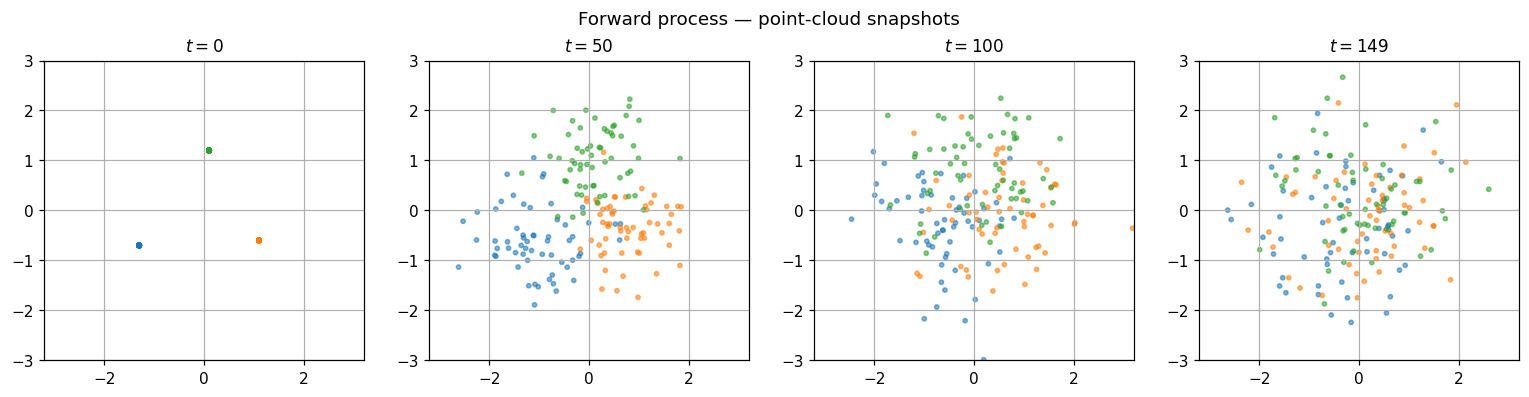

In [6]:
fig1, axes1 = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)
for ax, t in zip(axes1, [0, 50, 100, 149]):
    pts = fwd_all[t]
    ax.scatter(pts[:, 0], pts[:, 1], c=atom_colors, s=8, alpha=0.55)
    ax.set_title(f"$t = {t}$", fontsize=11)
    ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.0, 3.0)
fig1.suptitle("Forward process — point-cloud snapshots", fontsize=12)
fig1.savefig(OUT / "fwd_snapshots.png", bbox_inches="tight")
plt.show()
plt.close(fig1)

### B — Trajectory Curves for Selected Particles

For 8 representative particles, we draw the path $(x_0,\ldots,x_T)$ as a viridis-coloured polyline (blue=early, yellow=late). Green circles mark $x_0$, red crosses mark $x_T$.

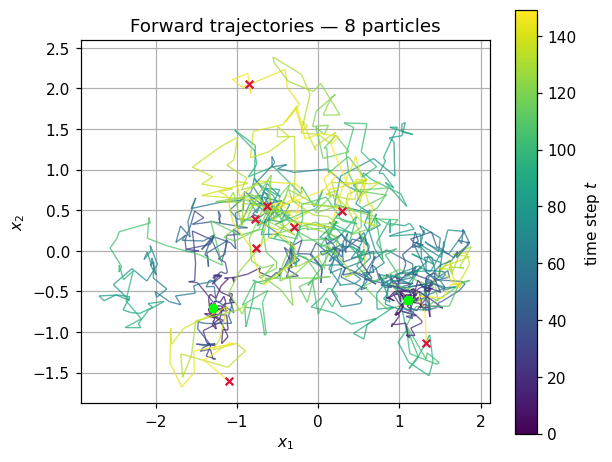

In [7]:
t_norm  = np.arange(T) / (T - 1)
seg_col = cm.viridis(t_norm)

fig2, ax2 = plt.subplots(figsize=(6, 5))
for pid in traj_ids:
    pts_traj = fwd_all[:, pid, :]
    segs = np.stack([pts_traj[:-1], pts_traj[1:]], axis=1)
    ax2.add_collection(LineCollection(segs, colors=seg_col, linewidths=0.9, alpha=0.75))
    ax2.scatter(pts_traj[0,0],  pts_traj[0,1],  marker='o', s=25, color='lime',    zorder=5)
    ax2.scatter(pts_traj[-1,0], pts_traj[-1,1], marker='x', s=25, color='crimson', zorder=5)
sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(0, T-1))
sm.set_array([])
fig2.colorbar(sm, ax=ax2, label="time step $t$")
ax2.set_title("Forward trajectories — 8 particles")
ax2.set_aspect("equal"); ax2.autoscale()
ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
fig2.savefig(OUT / "fwd_trajectories.png", bbox_inches="tight")
plt.show()
plt.close(fig2)

## Backward Process

Starting from fresh Gaussian noise $x_T \sim \mathcal{N}(0, I)$, we run the **exact**
reverse DDPM update for all $T = 150$ steps:
$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Bigl(x_t + (1-\alpha_t)\, s(x_t, t)\Bigr)
+ \sqrt{\beta_t}\,\eta_t, \qquad \eta_t \sim \mathcal{N}(0, I),
$$
with $\eta_T = 0$ (deterministic last step).

Array `bwd_all` has shape $(T+1, N, 2)$: index 0 is $x_T$ (pure noise),
index $T$ is $x_0$ (the recovered distribution).

**Display A — point-cloud snapshots** at denoising steps 0, 49, 99, 149
(corresponding roughly to forward $t = 149, 100, 50, 0$).

**Display B — trajectory curves** for the same 8 particles:
the plasma colormap runs from dark (early denoising = noisy) to bright
(late denoising = structured).

In [8]:
# Run full backward denoising  x_T -> x_{T-1} -> ... -> x_0
bwd_all = np.empty((T + 1, N, 2))   # bwd_all[0]=x_T, bwd_all[T]=recovered

xb = rng.standard_normal((N, 2))
bwd_all[0] = xb.copy()

for step, t in enumerate(range(T - 1, -1, -1)):
    sc    = score_mixture(xb, t)
    noise = rng.standard_normal(xb.shape) if t > 0 else np.zeros_like(xb)
    xb    = (xb + (1.0 - alpha[t]) * sc) / np.sqrt(alpha[t]) + np.sqrt(beta[t]) * noise
    bwd_all[step + 1] = xb

print(f"bwd_all: {bwd_all.shape}  recovered std: {bwd_all[-1].std(axis=0).round(3)}")

bwd_all: (151, 180, 2)  recovered std: [0.967 0.892]


### A — Point-Cloud Snapshots Along Denoising

As denoising progresses from pure noise to a recovered sample, the cloud collapses back toward the three original atom positions, demonstrating that the closed-form score provides an effective denoising signal.

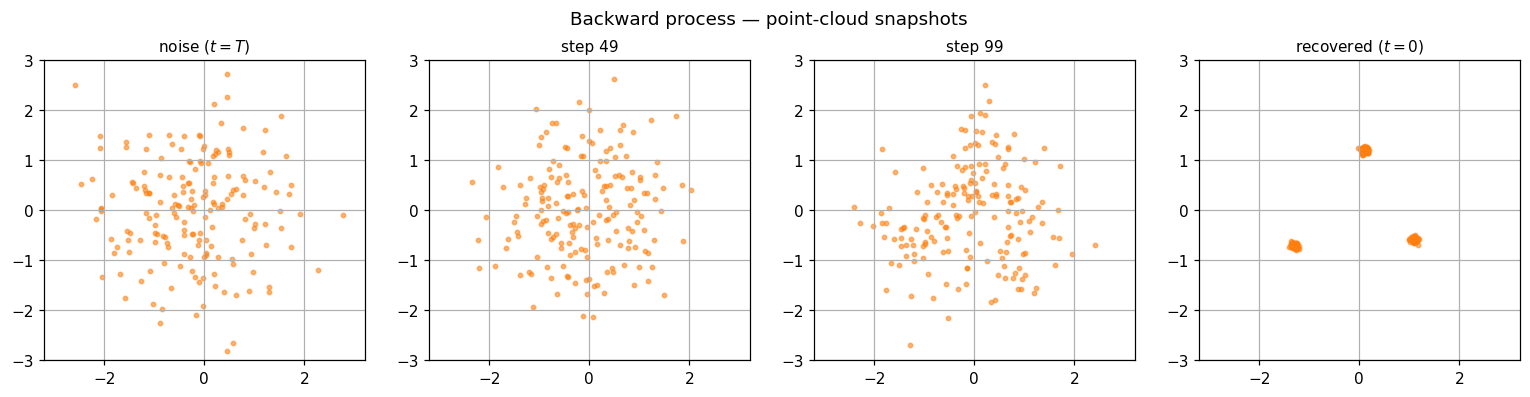

In [9]:
bwd_lbls = ["noise ($t=T$)", "step 49", "step 99", "recovered ($t=0$)"]

fig3, axes3 = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)
for ax, idx, lbl in zip(axes3, [0, 49, 99, 149], bwd_lbls):
    pts = bwd_all[idx]
    ax.scatter(pts[:, 0], pts[:, 1], color='tab:orange', s=8, alpha=0.55)
    ax.set_title(lbl, fontsize=10)
    ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.0, 3.0)
fig3.suptitle("Backward process — point-cloud snapshots", fontsize=12)
fig3.savefig(OUT / "bwd_snapshots.png", bbox_inches="tight")
plt.show()
plt.close(fig3)

### B — Trajectory Curves for Selected Particles

Denoising trajectories (plasma colourmap: dark purple=noisy, bright yellow=recovered). The paths are markedly more structured than the forward ones: they focus progressively toward the three atom positions.

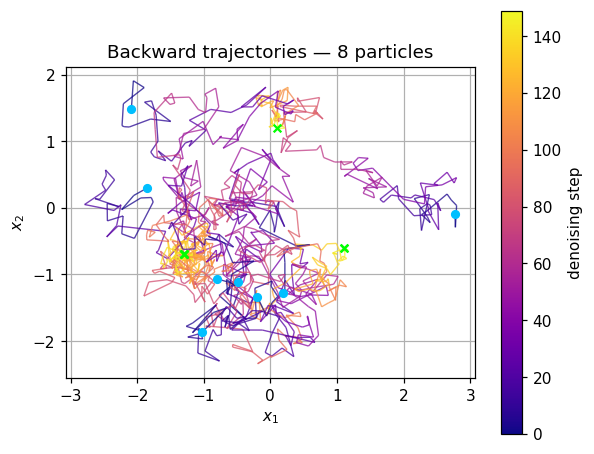

In [10]:
seg_col_b = cm.plasma(t_norm)

fig4, ax4 = plt.subplots(figsize=(6, 5))
for pid in traj_ids:
    pts_traj = bwd_all[:, pid, :]
    segs = np.stack([pts_traj[:-1], pts_traj[1:]], axis=1)
    ax4.add_collection(LineCollection(segs, colors=seg_col_b, linewidths=0.9, alpha=0.75))
    ax4.scatter(pts_traj[0,0],  pts_traj[0,1],  marker='o', s=25, color='deepskyblue', zorder=5)
    ax4.scatter(pts_traj[-1,0], pts_traj[-1,1], marker='x', s=25, color='lime',        zorder=5)
sm_b = plt.cm.ScalarMappable(cmap=cm.plasma, norm=plt.Normalize(0, T-1))
sm_b.set_array([])
fig4.colorbar(sm_b, ax=ax4, label="denoising step")
ax4.set_title("Backward trajectories — 8 particles")
ax4.set_aspect("equal"); ax4.autoscale()
ax4.set_xlabel("$x_1$"); ax4.set_ylabel("$x_2$")
fig4.savefig(OUT / "bwd_trajectories.png", bbox_inches="tight")
plt.show()
plt.close(fig4)

## Interactive Explorer

The widget below selects a forward time index $t \in \{0, \ldots, T-1\}$ and renders:
- **Left** — forward cloud at step $t$ (colour = atom of origin).
- **Right** — backward cloud at the complementary denoising step $T - 1 - t$
  (so $t=0$ shows the fully noisy backward state, and $t=T-1$ shows the recovered state).

Use the **Play** button for an animated sweep, or drag the slider manually.

## Static Snapshot

A $2\times4$ summary figure saved as `snippet.png`:
- **Top row** — four forward snapshots at $t = 0, 50, 100, 149$.
- **Bottom row** — four backward snapshots at equivalent denoising stages.

The cell is guarded by `STATIC_SNAPSHOT = True` and uses `plt.savefig` + `plt.close`
so it does not block automated execution.

snippet.png saved → snippet.png


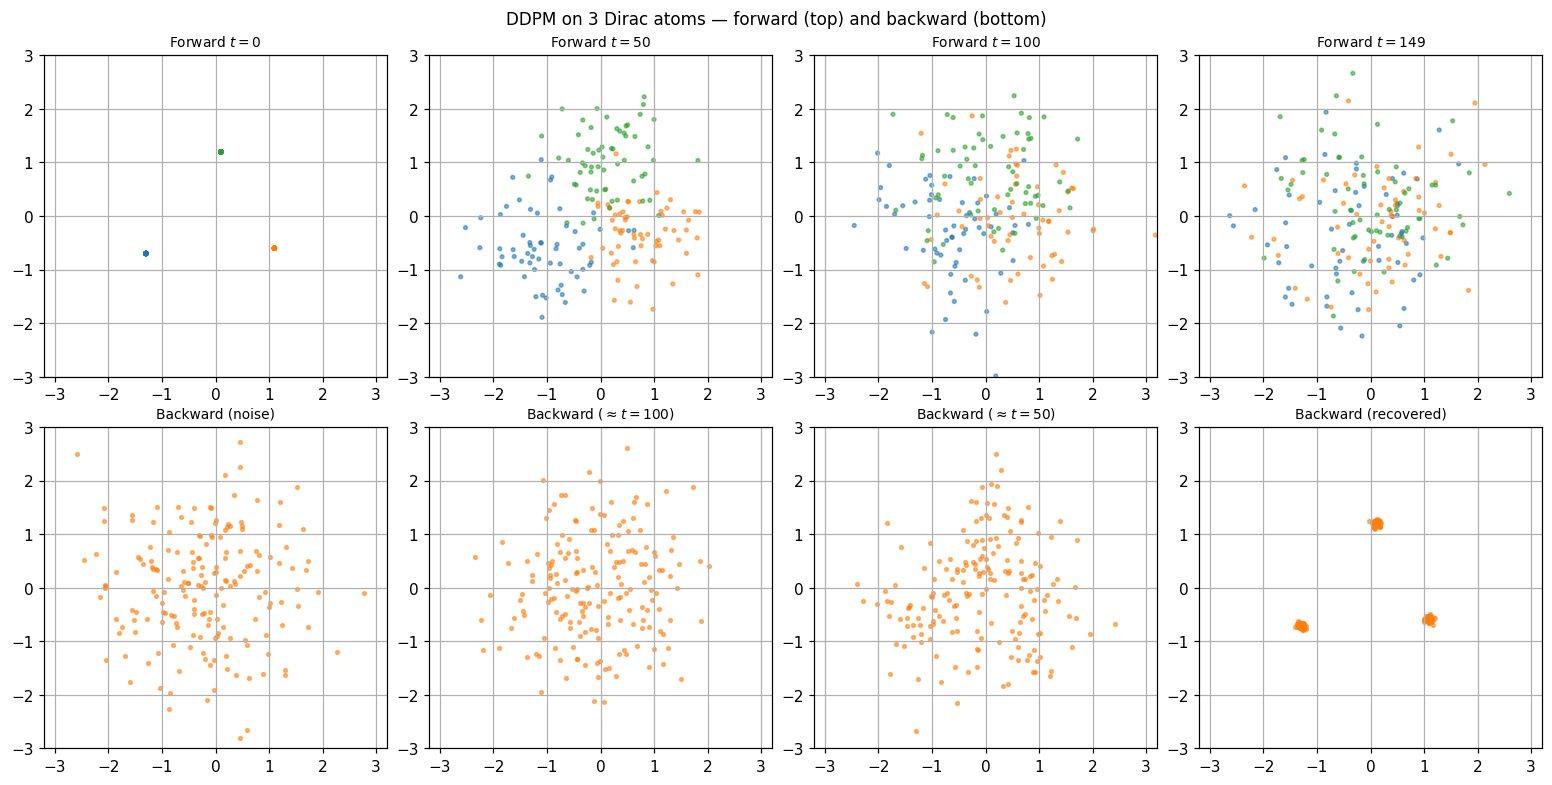

In [11]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    fig_s, axes_s = plt.subplots(2, 4, figsize=(14, 7), constrained_layout=True)
    # top row — forward
    fwd_snap_idx = [0, 50, 100, 149]
    fwd_labels   = ["$t=0$", "$t=50$", "$t=100$", "$t=149$"]
    for ax, tidx, lbl in zip(axes_s[0], fwd_snap_idx, fwd_labels):
        pts = fwd_all[tidx]
        ax.scatter(pts[:, 0], pts[:, 1], c=atom_colors, s=6, alpha=0.55)
        ax.set_title(f"Forward {lbl}", fontsize=9)
        ax.set_aspect("equal")
        ax.set_xlim(-3.2, 3.2);  ax.set_ylim(-3.0, 3.0)
    # bottom row — backward
    bwd_idx  = [0, 49, 99, 149]
    bwd_lbls = ["noise", r"$\approx t{=}100$", r"$\approx t{=}50$", "recovered"]
    for ax, bidx, lbl in zip(axes_s[1], bwd_idx, bwd_lbls):
        pts = bwd_all[bidx]
        ax.scatter(pts[:, 0], pts[:, 1], color='tab:orange', s=6, alpha=0.55)
        ax.set_title(f"Backward ({lbl})", fontsize=9)
        ax.set_aspect("equal")
        ax.set_xlim(-3.2, 3.2);  ax.set_ylim(-3.0, 3.0)
    fig_s.suptitle(
        "DDPM on 3 Dirac atoms — forward (top) and backward (bottom)",
        fontsize=11
    )
    fig_s.savefig(OUT / "snippet.png", bbox_inches="tight")
    plt.close(fig_s)
    print("snippet.png saved →", OUT / "snippet.png")
from IPython.display import Image, display
display(Image(filename=str(OUT / "snippet.png")))


## Takeaways

- **Closed-form score** — the Gaussian mixture structure of $p_t$ gives an analytic
  score, eliminating the need for a learned denoiser on this toy problem.
- **Full reversibility** — with the exact score the DDPM reverse chain precisely
  recovers the original Dirac atoms after $T$ steps.
- **Trajectory geometry** — forward trajectories spread outward from the clusters;
  reverse trajectories converge toward the atoms, guided by the score's gradient flow.
- **Noise schedule effect** — the linear $\beta$ schedule smoothly interpolates
  between structured data and isotropic Gaussian noise;
  a steeper schedule collapses structure faster.
- **Score singularity at $t=0$** — as $\bar\alpha_t \to 1$ the variance
  $1-\bar\alpha_t \to 0$, so the score diverges near the atoms;
  the small $10^{-12}$ floor in the denominator prevents numerical overflow.

## Bibliography

- Ho, J., Jain, A., & Abbeel, P. (2020).
  **Denoising Diffusion Probabilistic Models.**
  *NeurIPS 2020.* [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)
- Song, Y., & Ermon, S. (2019).
  **Generative Modeling by Estimating Gradients of the Data Distribution.**
  *NeurIPS 2019.* [arXiv:1907.05600](https://arxiv.org/abs/1907.05600)
- Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2021).
  **Score-Based Generative Modeling through Stochastic Differential Equations.**
  *ICLR 2021.* [arXiv:2011.13456](https://arxiv.org/abs/2011.13456)
- Vincent, P. (2011).
  **A Connection Between Score Matching and Denoising Autoencoders.**
  *Neural Computation, 23*(7), 1661–1674.
- Luo, C. (2022).
  **Understanding Diffusion Models: A Unified Perspective.**
  [arXiv:2208.11970](https://arxiv.org/abs/2208.11970)